In [2]:
pip install xgboost

  Using cached xgboost-3.2.0-py3-none-win_amd64.whl.metadata (2.1 kB)
Using cached xgboost-3.2.0-py3-none-win_amd64.whl (101.7 MB)
Note: you may need to restart the kernel to use updated packages.


In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import GradientBoostingRegressor
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import mean_absolute_error
import xgboost as xgb
import pickle
import os

In [4]:
TRAIN_PATH = "../outputs/clean_train.parquet"
TEST_PATH  = "../outputs/clean_test.parquet"
OUT_DIR    = "../outputs/models"
os.makedirs(OUT_DIR, exist_ok=True)

In [6]:
train = pd.read_parquet(TRAIN_PATH)
test  = pd.read_parquet(TEST_PATH)

print(f"\nTarget variable (actual_time) stats:")
print(f"  Train — mean: {train['actual_time'].mean():.1f} min  "
      f"median: {train['actual_time'].median():.1f} min  "
      f"max: {train['actual_time'].max():.1f} min")
print(f"  Test  — mean: {test['actual_time'].mean():.1f} min  "
      f"median: {test['actual_time'].median():.1f} min  "
      f"max: {test['actual_time'].max():.1f} min")

Train shape : (103126, 29)
Test shape  : (39376, 29)

Target variable (actual_time) stats:
  Train — mean: 414.6 min  median: 137.0 min  max: 4532.0 min
  Test  — mean: 438.7 min  median: 127.0 min  max: 4154.0 min


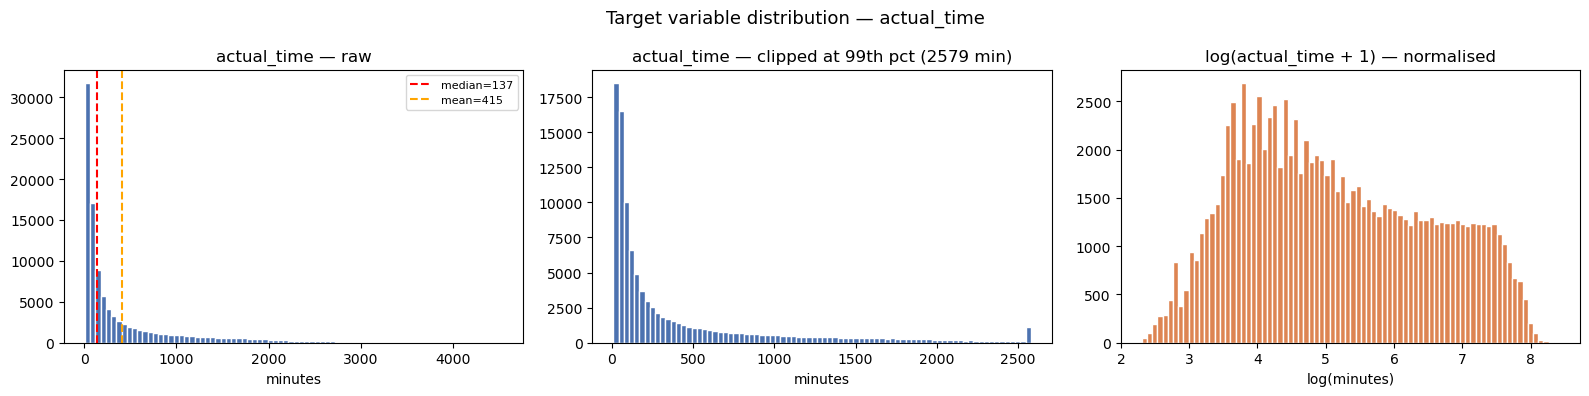

Skewness (raw)    : 2.08
Skewness (log)    : 0.28


In [8]:
fig, axes = plt.subplots(1, 3, figsize=(16, 4))

# Raw distribution
axes[0].hist(train['actual_time'], bins=80, color='#4C72B0', edgecolor='white')
axes[0].set_title("actual_time — raw")
axes[0].set_xlabel("minutes")
axes[0].axvline(train['actual_time'].median(), color='red',
                linestyle='--', label=f"median={train['actual_time'].median():.0f}")
axes[0].axvline(train['actual_time'].mean(), color='orange',
                linestyle='--', label=f"mean={train['actual_time'].mean():.0f}")
axes[0].legend(fontsize=8)

# Clipped at 99th percentile
cap = train['actual_time'].quantile(0.99)
axes[1].hist(train['actual_time'].clip(upper=cap), bins=80,
             color='#4C72B0', edgecolor='white')
axes[1].set_title(f"actual_time — clipped at 99th pct ({cap:.0f} min)")
axes[1].set_xlabel("minutes")

# Log distribution
axes[2].hist(np.log1p(train['actual_time']), bins=80,
             color='#DD8452', edgecolor='white')
axes[2].set_title("log(actual_time + 1) — normalised")
axes[2].set_xlabel("log(minutes)")

plt.suptitle("Target variable distribution — actual_time", fontsize=13)
plt.tight_layout()
plt.show()

print(f"Skewness (raw)    : {train['actual_time'].skew():.2f}")
print(f"Skewness (log)    : {np.log1p(train['actual_time']).skew():.2f}")


In [9]:
def build_features(df):
    """
    Build feature matrix for ETA prediction.
    Only uses tabular features — no graph.
    This is the baseline feature set.
    """
    X = pd.DataFrame()

    # OSRM predictions — the core signal
    X['osrm_time']         = df['osrm_time']
    X['osrm_distance']     = df['osrm_distance']
    X['segment_osrm_time'] = df['segment_osrm_time']

    # Route type — FTL vs Carting behave differently
    X['is_carting'] = (df['route_type'] == 'Carting').astype(int)

    # Time features — delays vary by when trip was created
    X['hour_of_day']     = df['hour_of_day']
    X['day_of_week']     = df['day_of_week']
    X['is_night']        = df['is_night']
    X['is_peak_evening'] = df['is_peak_evening']
    X['is_weekend']      = df['is_weekend']

    # SLA pressure — cutoff trips may be prioritised differently
    X['is_cutoff'] = df['is_cutoff'].astype(int)

    # Derived — OSRM ratio of segment to total
    # Captures how much of the trip this segment represents
    X['segment_ratio'] = (
        df['segment_osrm_time'] /
        df['osrm_time'].replace(0, np.nan)
    ).fillna(0).clip(0, 1)

    return X

X_train = build_features(train)
X_test  = build_features(test)

# Log-transform target
y_train = np.log1p(train['actual_time'])
y_test  = np.log1p(test['actual_time'])

# Keep raw target for final evaluation
y_train_raw = train['actual_time']
y_test_raw  = test['actual_time']

print(f"Feature matrix shape — train : {X_train.shape}")
print(f"Feature matrix shape — test  : {X_test.shape}")
print(f"\nFeatures used:")
for col in X_train.columns:
    print(f"  {col}")
print(f"\nAny nulls in features: {X_train.isnull().sum().sum()}")

Feature matrix shape — train : (103126, 11)
Feature matrix shape — test  : (39376, 11)

Features used:
  osrm_time
  osrm_distance
  segment_osrm_time
  is_carting
  hour_of_day
  day_of_week
  is_night
  is_peak_evening
  is_weekend
  is_cutoff
  segment_ratio

Any nulls in features: 0


In [10]:
def evaluate(y_true_raw, y_pred_raw, model_name):
    """
    Evaluate predictions against:
    1. MAE — Mean Absolute Error in minutes
    2. within_15pct — % of trips with predicted ETA within 15% of actual
    """
    mae = mean_absolute_error(y_true_raw, y_pred_raw)

    # % of trips where |pred - actual| / actual <= 0.15
    pct_error = np.abs(y_pred_raw - y_true_raw) / y_true_raw.replace(0, np.nan)
    within_15 = (pct_error <= 0.15).mean() * 100

    print(f"\n  {model_name}")
    print(f"    MAE            : {mae:.2f} min")
    print(f"    Within 15%     : {within_15:.2f}%")

    return {'model': model_name, 'mae': mae, 'within_15pct': within_15}


In [11]:
lr = LinearRegression()
lr.fit(X_train, y_train)

# Predict and inverse log transform
y_pred_lr = np.expm1(lr.predict(X_test))
y_pred_lr = np.clip(y_pred_lr, 0, None)   # no negative predictions

results = []
results.append(evaluate(y_test_raw, y_pred_lr, "Linear Regression"))


  Linear Regression
    MAE            : 175.12 min
    Within 15%     : 27.00%


In [12]:
xgb_model = xgb.XGBRegressor(
    n_estimators      = 500,
    max_depth         = 6,
    learning_rate     = 0.05,
    subsample         = 0.8,
    colsample_bytree  = 0.8,
    min_child_weight  = 10,
    random_state      = 42,
    n_jobs            = -1,
    verbosity         = 0,
)

xgb_model.fit(
    X_train, y_train,
    eval_set              = [(X_test, y_test)],
    verbose               = False,
)

y_pred_xgb = np.expm1(xgb_model.predict(X_test))
y_pred_xgb = np.clip(y_pred_xgb, 0, None)

results.append(evaluate(y_test_raw, y_pred_xgb, "XGBoost"))


  XGBoost
    MAE            : 55.45 min
    Within 15%     : 50.46%


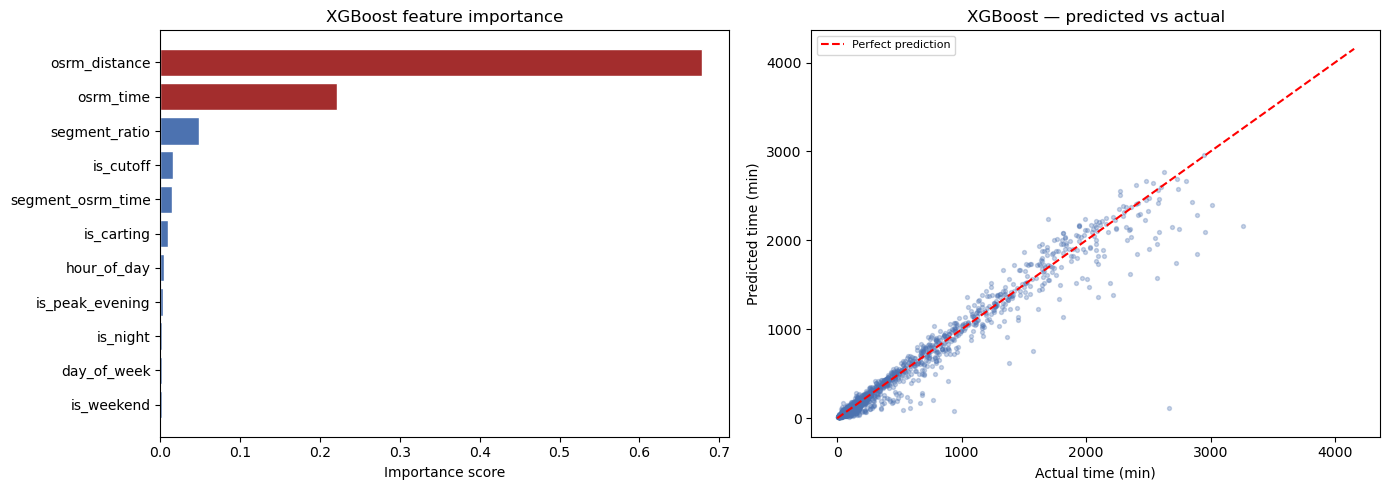

In [13]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# ── XGBoost feature importance ─────────────────────────────────────────
importance = pd.Series(
    xgb_model.feature_importances_,
    index=X_train.columns
).sort_values(ascending=True)

colors = ['#A32D2D' if v > 0.15 else '#BA7517' if v > 0.05 else '#4C72B0'
          for v in importance.values]

axes[0].barh(importance.index, importance.values,
             color=colors, edgecolor='white')
axes[0].set_title("XGBoost feature importance")
axes[0].set_xlabel("Importance score")

# ── Predicted vs actual scatter ────────────────────────────────────────
sample = np.random.choice(len(y_test_raw), 2000, replace=False)
axes[1].scatter(y_test_raw.iloc[sample], y_pred_xgb[sample],
                alpha=0.3, s=8, color='#4C72B0')
axes[1].plot([0, y_test_raw.max()], [0, y_test_raw.max()],
             color='red', linestyle='--', linewidth=1.5, label='Perfect prediction')
axes[1].set_xlabel("Actual time (min)")
axes[1].set_ylabel("Predicted time (min)")
axes[1].set_title("XGBoost — predicted vs actual")
axes[1].legend(fontsize=8)

plt.tight_layout()
plt.show()

In [14]:
print("=" * 55)
print("  BASELINE MODEL COMPARISON")
print("=" * 55)
print(f"  {'Model':<25} {'MAE (min)':>10} {'Within 15%':>12}")
print("-" * 55)
for r in results:
    print(f"  {r['model']:<25} {r['mae']:>10.2f} {r['within_15pct']:>11.2f}%")
print("=" * 55)
print(f"\n  Baseline to beat in Phase 3b:")
print(f"    MAE        < {min(r['mae'] for r in results):.2f} min")
print(f"    Within 15% > {max(r['within_15pct'] for r in results):.2f}%")

  BASELINE MODEL COMPARISON
  Model                      MAE (min)   Within 15%
-------------------------------------------------------
  Linear Regression             175.12       27.00%
  XGBoost                        55.45       50.46%

  Baseline to beat in Phase 3b:
    MAE        < 55.45 min
    Within 15% > 50.46%


In [15]:
print(train[['osrm_distance', 'osrm_time', 
             'segment_osrm_time', 'actual_time']].corr().round(3))

                   osrm_distance  osrm_time  segment_osrm_time  actual_time
osrm_distance              1.000      0.999              0.153        0.979
osrm_time                  0.999      1.000              0.161        0.978
segment_osrm_time          0.153      0.161              1.000        0.156
actual_time                0.979      0.978              0.156        1.000


In [19]:
from sklearn.model_selection import TimeSeriesSplit, cross_val_score

# Sort by trip creation time for temporal CV
train_sorted = train.sort_values('trip_creation_time').reset_index(drop=True)
X_cv = build_features(train_sorted)
y_cv = np.log1p(train_sorted['actual_time'])

tscv = TimeSeriesSplit(n_splits=5)

print("Running 5-fold TimeSeriesSplit cross-validation...")
print("(trains on past, validates on future — no data leakage)\n")

cv_scores = []
for fold, (train_idx, val_idx) in enumerate(tscv.split(X_cv), 1):
    X_tr, X_val = X_cv.iloc[train_idx], X_cv.iloc[val_idx]
    y_tr, y_val = y_cv.iloc[train_idx], y_cv.iloc[val_idx]
    y_val_raw   = train_sorted['actual_time'].iloc[val_idx]

    m = xgb.XGBRegressor(
        n_estimators=500, max_depth=6, learning_rate=0.05,
        subsample=0.8, colsample_bytree=0.8,
        min_child_weight=10, random_state=42,
        n_jobs=-1, verbosity=0
    )
    m.fit(X_tr, y_tr, verbose=False)
    y_pred_raw = np.clip(np.expm1(m.predict(X_val)), 0, None)

    mae = mean_absolute_error(y_val_raw, y_pred_raw)
    pct_err = np.abs(y_pred_raw - y_val_raw) / y_val_raw.replace(0, np.nan)
    within15 = (pct_err <= 0.15).mean() * 100

    cv_scores.append({'fold': fold, 'mae': mae, 'within_15pct': within15,
                      'train_size': len(train_idx), 'val_size': len(val_idx)})

    print(f"  Fold {fold} — train: {len(train_idx):,}  val: {len(val_idx):,}  "
          f"MAE: {mae:.2f}  Within15%: {within15:.2f}%")

cv_df = pd.DataFrame(cv_scores)
print(f"\n  CV MAE        — mean: {cv_df['mae'].mean():.2f}  "
      f"std: {cv_df['mae'].std():.2f}")
print(f"  CV Within 15% — mean: {cv_df['within_15pct'].mean():.2f}%  "
      f"std: {cv_df['within_15pct'].std():.2f}%")
print(f"\n  Test set MAE        : 55.45 min")
print(f"  Test set Within 15% : 50.46%")


Running 5-fold TimeSeriesSplit cross-validation...
(trains on past, validates on future — no data leakage)

  Fold 1 — train: 17,191  val: 17,187  MAE: 69.99  Within15%: 41.64%
  Fold 2 — train: 34,378  val: 17,187  MAE: 56.04  Within15%: 47.72%
  Fold 3 — train: 51,565  val: 17,187  MAE: 61.31  Within15%: 50.01%
  Fold 4 — train: 68,752  val: 17,187  MAE: 50.21  Within15%: 52.85%
  Fold 5 — train: 85,939  val: 17,187  MAE: 55.54  Within15%: 50.04%

  CV MAE        — mean: 58.62  std: 7.47
  CV Within 15% — mean: 48.45%  std: 4.22%

  Test set MAE        : 55.45 min
  Test set Within 15% : 50.46%


In [20]:
baseline = {
    'model'        : xgb_model,
    'features'     : X_train.columns.tolist(),
    'metrics'      : results,
    'mae'          : 55.45,
    'within_15pct' : 50.46,
    'cv_mae_mean'  : 58.62,
    'cv_mae_std'   : 7.47,
    'cv_within15_mean' : 48.45,
    'cv_within15_std'  : 4.22,
    'description'  : 'XGBoost baseline — tabular features only, no graph. CV confirmed no overfitting.'
}

model_path = f"{OUT_DIR}/baseline_model.pkl"
with open(model_path, 'wb') as f:
    pickle.dump(baseline, f)